In [98]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market_v2 import Market

In [89]:
from joblib import dump, load

market = load(project_root / "results/market_simulation_final_2.joblib")
market_model = load(project_root / 'results/market_model_GJR.joblib')

In [90]:
#base_w=np.array([.35, .25, .2, .2]) # try less vol_premia and more sector, makes sense to have less vol premia
market = Market(20, 3, market_model, rf = 0.0001, market_scale_arch=100, random_seed=42, base_w=np.array([.35, .15, .3, .2]))

In [99]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [100]:
N = 20 # n_assets
T = 10 # n_timeperiods - the amount the model sees ahead
K = 100 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_simulations = 50

trade_cost = 0.001 # 5bps - 20bps

In [93]:
scenarios = generate_scenarios(K, T, N, 'weekly', market)

## MPC

In [101]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

from src.utils import simulate_target_weight_portfolio

In [102]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.5, trade=trade_cost, risk_type='semi_variance', cvar_alpha=0.90)

In [103]:
controller.is_QP_and_DPP()

(True, True)

In [15]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner', leave=False):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [104]:
import src.simulation_generation
from importlib import reload
reload(src.simulation_generation)
from src.simulation_generation import generate_dataset, load_simulation

In [ ]:
from src.simulation_generation import generate_dataset

# NOTE: This will OVERWRITE existing dataset.

#generate_dataset(n_simulations, n_steps, freq, market, K,T,N, project_root / "datasets/trial_3asset20idio")

In [107]:
actual_traj, market_return, context = load_simulation(project_root / 'datasets/trial_3asset20idio', 0)

In [109]:
from src.utils import FREQ_COEFF
MAGIC_NUMBER = 20

In [111]:
from tqdm.notebook import tqdm
import warnings

full_stats = []
dataset_path = project_root / 'datasets/trial_3asset20idio'

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))
    eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):

        full_stats.append([])

        actual_traj, market_return, context = load_simulation(dataset_path, i)
        full_date_index = context['market'].index

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}', leave=False):

            next_date = actual_traj.index[step+1]
            current_date = actual_traj.index[step]

            current_loc = full_date_index.get_loc(current_date)

            start, end = full_date_index[current_loc - MAGIC_NUMBER + 1], full_date_index[current_loc] # loc is exclusive

            scenarios = generate_scenarios(K ,T, N, freq, market, burn=0,
                                           initial_market_returns=context['market'].loc[start:end],
                                           initial_market_vols=context['market_vol'].loc[start:end], 
                                           initial_sector_returns=context['sectors'].loc[start:end].to_numpy())
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve(solver='SCS')
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.loc[next_date]])

            MPC_sim.append(x_next)

            full_stats[i].append(stats)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return[1:]])).cumprod() * 100
        eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, actual_traj.iloc[1:].T, trading_cost=trade_cost)

Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 2:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 3:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 4:   0%|          | 0/52 [00:00<?, ?it/s]

...

simulation 18:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 19:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 20:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 21:   0%|          | 0/52 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
dump(full_stats, project_root / "results/stats/SCS_idio20_3assets.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\stats\\SCS_idio20_3assets.joblib']

## Results

In [61]:
from joblib import dump
dump(MPC_sims, project_root / "results/idio_20/MPC_sims_3asset_semivar.joblib")
dump(market_sims, project_root / "results/idio_20/market_sims_3asset_semivar.joblib")
dump(eq_sims, project_root / "results/idio_20/eq_sims_3asset_semivar.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\idio_20\\eq_sims_3asset_semivar.joblib']

In [14]:
from joblib import load
MPC_sims = load(project_root / "results/idio_20/MPC_sims_3asset_semivar.joblib")
market_sims = load(project_root / "results/idio_20/market_sims_3asset_semivar.joblib")
eq_sims = load(project_root / "results/idio_20/eq_sims_3asset_semivar.joblib")

In [13]:
market = load(project_root / "datasets/market.joblib")

In [113]:
df = pd.DataFrame(MPC_sims[0]) # 36, 48 is interesting too in var
eq_df = pd.DataFrame(eq_sims[0])

In [112]:
np.linalg.norm(MPC_sims, 2, axis=(1,2))

array([370.45958597, 270.86566646, 278.64871653, 323.55206411,
       230.81449689, 239.11871888, 275.71528102, 250.54504032,
       272.11482486, 281.49874904, 200.62061809, 341.01203366,
       252.67259298, 188.475677  , 243.43953715, 254.14755683,
       295.76091348, 325.59945645, 323.09583633, 277.48521694,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ])

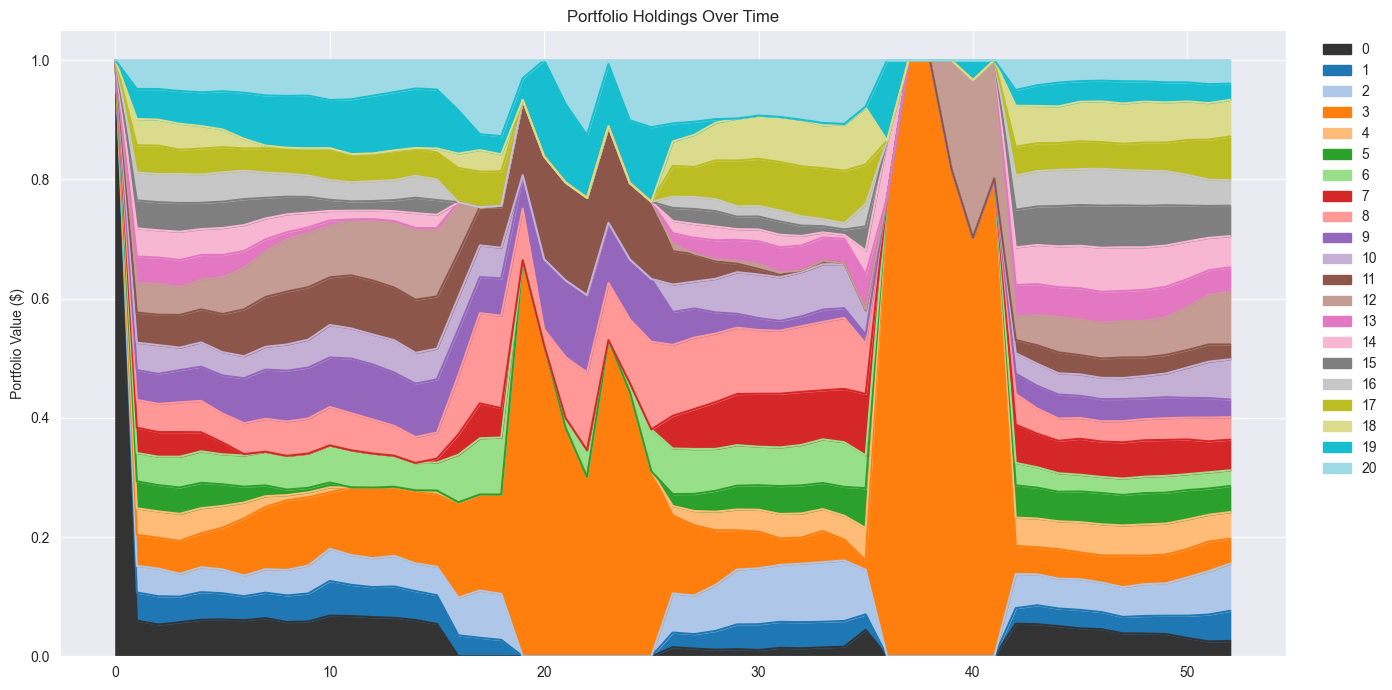

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# all except cash
asset_colors = sns.color_palette("tab20", market.n_assets)

# add cash color at the start
colors =  [(0.2, 0.2, 0.2)] + asset_colors

weights = df.div(df.sum(axis=1), axis=0)
weights[weights < 0] = 0

ax = weights.plot.area(
    figsize=(14, 7),
    #cmap=cmap
    color=colors
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Portfolio Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [115]:
sector_holdings = pd.DataFrame()

sector_holdings['cash'] = df[0]
df_ = df.drop(0, axis=1)

for sector in range(market.n_sectors):
    sector_holdings[sector] = df_.T.iloc[market.sectors == sector].sum(axis=0)

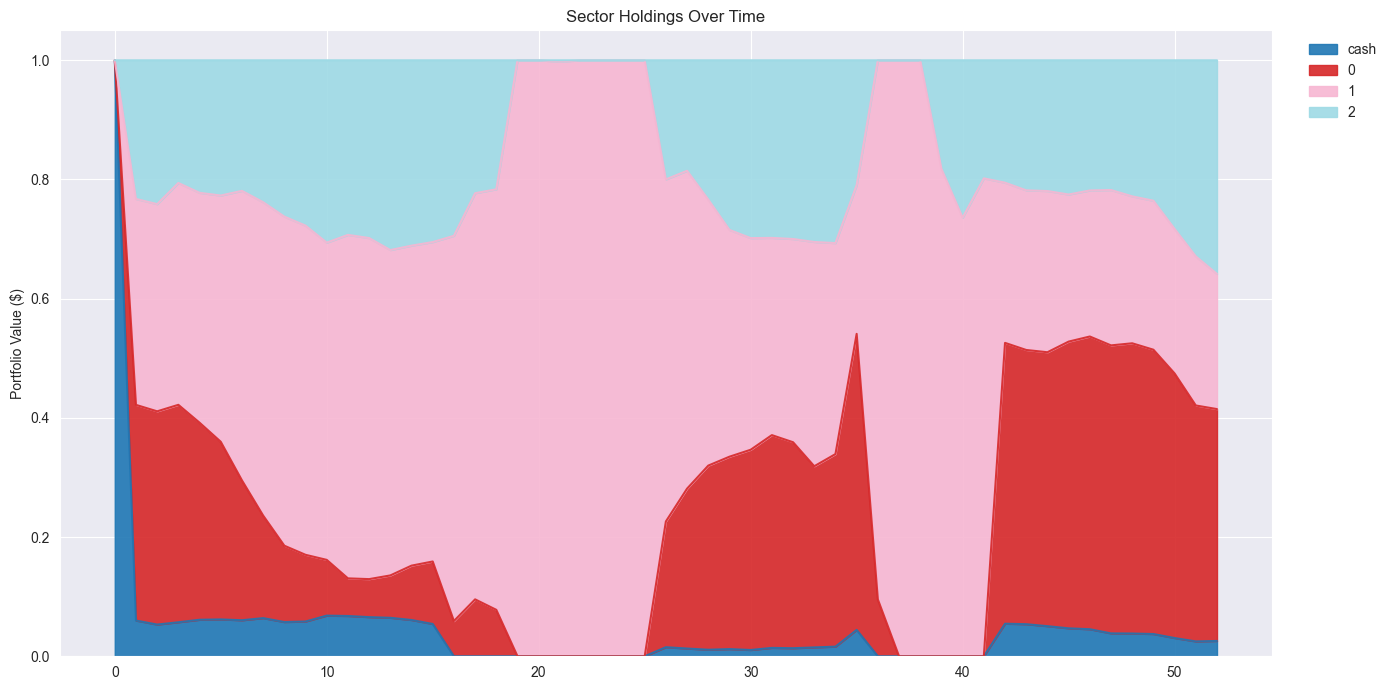

In [116]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap("tab20")

sector_weights = sector_holdings.div(df.sum(axis=1), axis=0)
sector_weights[sector_weights < 0] = 0

ax = sector_weights.plot.area(
    figsize=(14, 7),
    cmap=cmap,
    alpha=0.9
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Sector Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [117]:
market.summary()

,alpha,beta,idio vols,sector,sector_coeffs,sector_vols,vol_premium
0,-0.000143,0.396020,0.008348,2,0.379770,0.011978,0.971040
1,-0.000005,0.467246,0.010067,2,0.481968,0.011978,1.170032
2,0.000122,0.692753,0.014484,1,0.864035,0.009084,-1.890303
3,0.000051,0.392971,0.007577,0,0.477128,0.008429,0.775943
4,0.000054,0.332991,0.006896,0,0.448052,0.008429,0.912121
5,0.000003,0.390159,0.007618,1,0.461682,0.009084,0.912377
6,-0.000120,0.578360,0.012067,0,0.751395,0.008429,1.520558
7,0.000079,0.465646,0.009975,1,0.579956,0.009084,1.177997
8,0.000143,0.371852,0.007549,1,0.484310,0.009084,-0.838831
9,-0.000110,0.538711,0.010590,2,0.471832,0.011978,1.057162


In [118]:
rm = pd.Series(market_sims[0])

In [119]:
rm = rm.pct_change()
rm = rm - rm.mean()
m_volatility = (rm**2).ewm(span=20, adjust=False).mean()
m_fast = (rm**2).ewm(span=2, adjust=False).mean()

<Axes: >

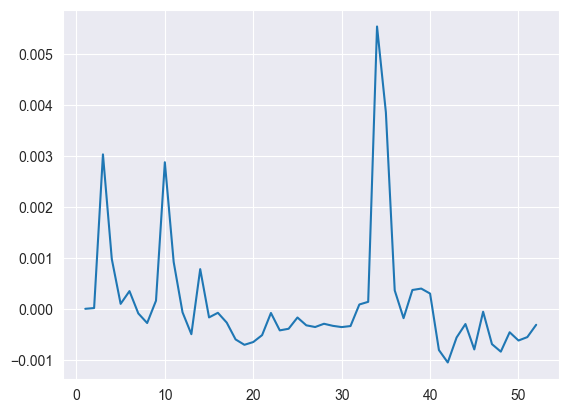

In [120]:
(m_fast - m_volatility).plot()

In [122]:
mm = pd.DataFrame(market_sims[0])

In [123]:
market_sims.std(axis=1)

array([11.63141646,  9.62331483,  5.19539717,  4.67936538,  5.67720632,
        3.8313498 ,  9.87224961,  4.24537053, 13.23877961,  2.55437132,
        6.3450673 ,  9.1207396 ,  6.1430665 ,  6.47316587,  6.61851623,
        7.14556585,  5.68325079,  8.39229979,  4.00158282,  7.17274209,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [124]:
mm.rename(columns={0: 'market'}, inplace=True)

<Axes: >

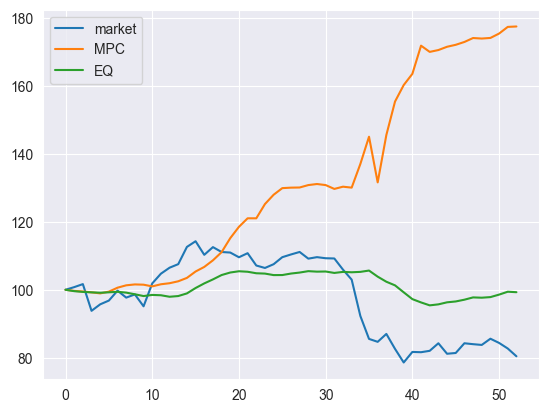

In [125]:
mm.plot(label='market', legend=True)
df.sum(axis=1).plot(label='MPC', legend=True)
eq_df.sum(axis=1).plot(label='EQ', legend=True)


In [126]:
w_ = weights.T.loc[1:]

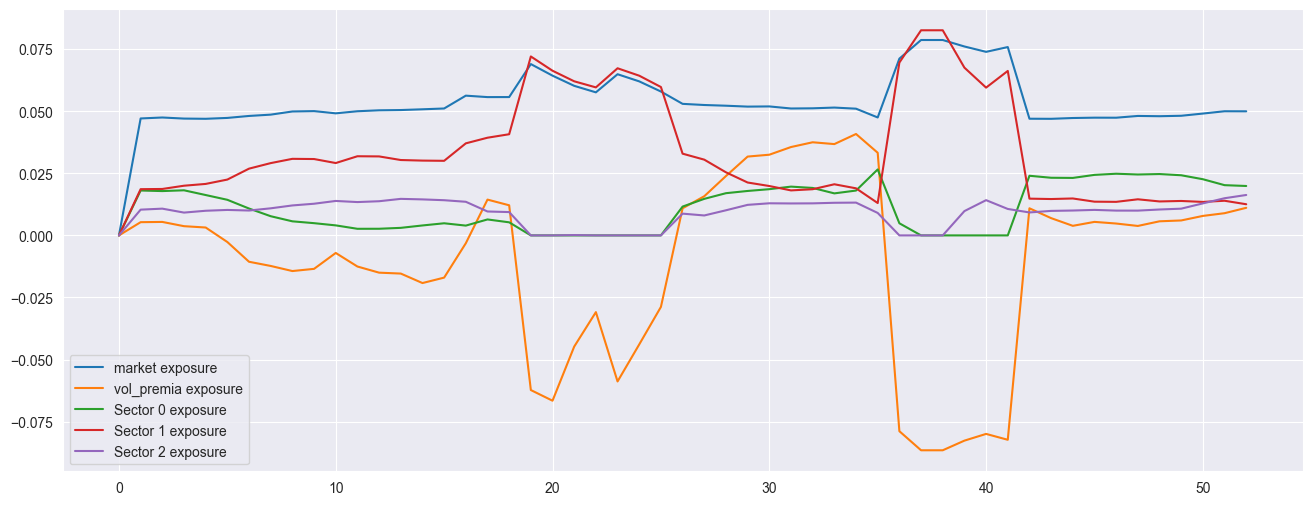

In [127]:
# Plot exposures to factors from coefficients

fig, ax = plt.subplots(1,1, figsize=(16,6))

(weights @ np.hstack([0, market.betas]) / market.betas.sum()).plot(label = 'market exposure', ax=ax)
(weights @ np.hstack([0, market.vol_premia]) / np.linalg.norm(market.vol_premia, 1)).plot(label = 'vol_premia exposure', ax=ax)

sector_exps = []
sector_scale = market.sector_coeffs.sum()

for sector in range(market.n_sectors):
    sector_mask = market.sectors == sector
    sector_exp = market.sector_coeffs[sector_mask] @ w_.iloc[sector_mask]
    sector_exps.append(sector_exp)
    (sector_exp / sector_scale).plot(label = f'Sector {sector} exposure', ax=ax)

ax.legend()

In [128]:
market_sims = pd.DataFrame(market_sims)
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims.sum(axis=2))

In [129]:
import src.portfolio_analysis
from importlib import reload
reload(src.portfolio_analysis)

<module 'src.portfolio_analysis' from 'C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\src\\portfolio_analysis.py'>

In [136]:
MPC_sims = MPC_sims.iloc[:20]
eq_sims = eq_sims.iloc[:20]
market_sims = market_sims.iloc[:20]

In [137]:
from src.portfolio_analysis import plot_simulations, compute_returns, compute_metrics

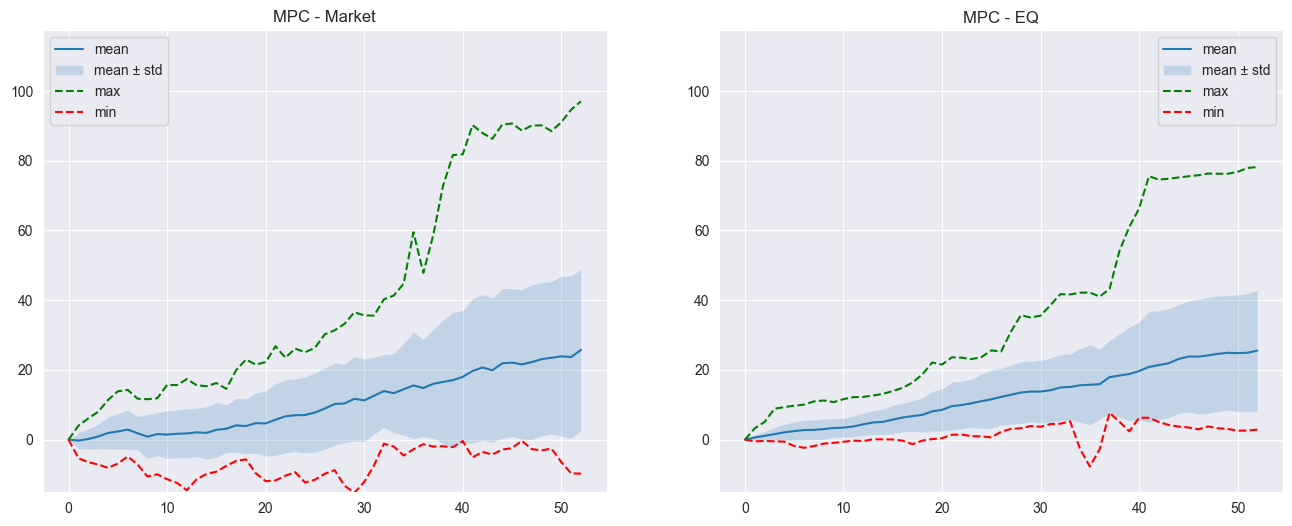

In [138]:
plot_simulations([MPC_sims - market_sims, MPC_sims - eq_sims], labels=["MPC - Market", 'MPC - EQ'])

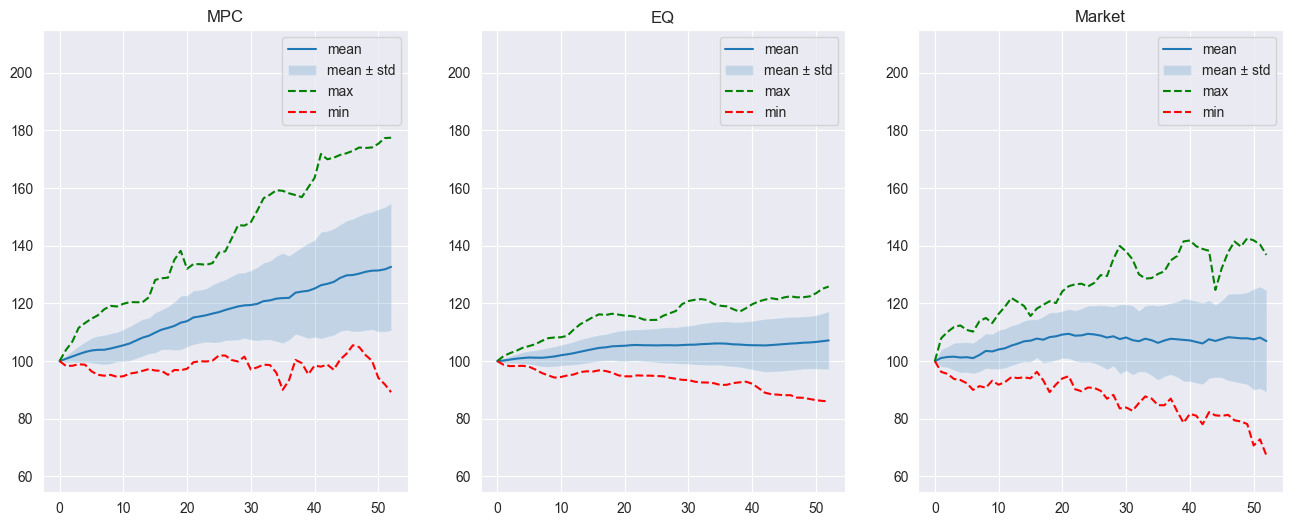

In [139]:
plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'])

In [140]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [141]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

mpc_capm = []
eq_capm = []

for col in returns['MPC'].columns:
    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(returns['Market'][col])).fit()
    mpc_capm.append(lm)

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(returns['Market'][col])).fit()
    eq_capm.append(lm)

In [142]:
capm_coeffs = pd.DataFrame(index=['MPC alpha', 'MPC beta', 'EQ alpha', 'EQ beta'])

for i in range(n_simulations):
    capm_coeffs[i] = np.hstack([mpc_capm[i].params.values, eq_capm[i].params.values])

IndexError: list index out of range

In [41]:
from src.portfolio_analysis import conf_int_high, conf_int_low, conf_int_p

In [42]:
capm_summary = capm_coeffs.agg(['mean', 'std', 'sem', conf_int_low, conf_int_high, conf_int_p], axis=1)
capm_summary # NOTE: betas are with mean (2 sided), alphas with 0 (greater) (so betas p are not very meaningful)

,mean,std,sem,conf_int_low,conf_int_high,conf_int_p
MPC alpha,0.005390,0.002060,0.000291,0.004902,inf,0.000000
MPC beta,0.152380,0.171485,0.024252,0.103644,0.201115,1.000000
EQ alpha,0.000728,0.001896,0.000268,0.000278,inf,0.004573
EQ beta,0.076793,0.034281,0.004848,0.067050,0.086535,1.000000


In [43]:
market.base_w

array([0.35, 0.15, 0.3 , 0.2 ])

In [143]:
metrics = compute_metrics(returns, rf)
metrics # ADD VaR, CVaR to metrics

,MPC,EQ,Market
mean of mean returns,0.005311,0.001271,0.001371
std of mean returns,0.003206,0.001829,0.003284
se of mean returns,0.000717,0.000409,0.000734
ci_low of mean returns,0.003810,0.000415,-0.000166
ci high of mean returns,0.006811,0.002127,0.002908
mean of sharpe ratios,0.445018,0.213228,0.061477
std of sharpe ratios,0.251044,0.353492,0.130679
se of sharpe ratios,0.056135,0.079043,0.029221
ci_low of sharpe ratios,0.327525,0.047788,0.000317
ci high of sharpe ratios,0.562510,0.378667,0.122636


In [159]:
_, _, context = load_simulation(project_root / 'datasets', 0)

In [145]:
mpc_factor_model = []
mpc_params_df = pd.DataFrame()
eq_params_df = pd.DataFrame()

for i, col in enumerate(returns['MPC'].columns):
    _, _, context = load_simulation(dataset_path, i)

    market_factor = market._calc_smooth_factor(context['market'], 'ewm', 20)

    vol_factor = market._calc_smooth_factor(context['market_vol'], 'ewm', 20)
    vol_factor = context['market_vol'].loc[vol_factor.index] - vol_factor

    sector_factors = market._calc_smooth_factor(context['sectors'], 'ewm', 20)
    
    Factors = pd.concat([market_factor, vol_factor, sector_factors], axis=1)
    Factors.columns = ['Market', 'vol_premia'] + [f"sector {j}" for j in range(market.n_sectors)]

    Factors = ((1 + Factors).resample('W-FRI')).prod()
    Factors = Factors.iloc[-52:]
    Factors.index = returns['MPC'][col].index

    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(Factors)).fit()
    mpc_factor_model.append(lm)

    mpc_params_df[i] = lm.params

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(Factors)).fit()
    eq_params_df[i] = lm.params

<Axes: >

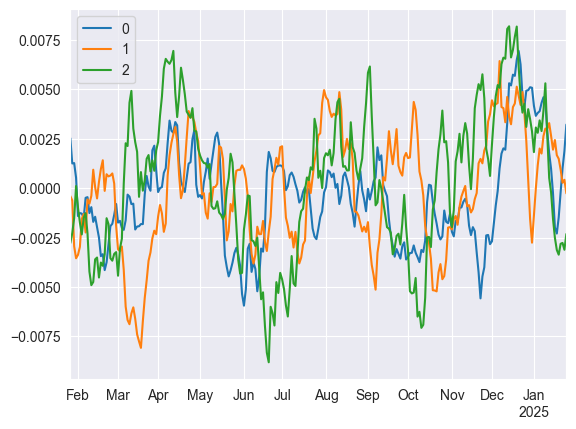

In [146]:
sector_factors[[0,1,2]].plot()

(-2.0, 1.5)

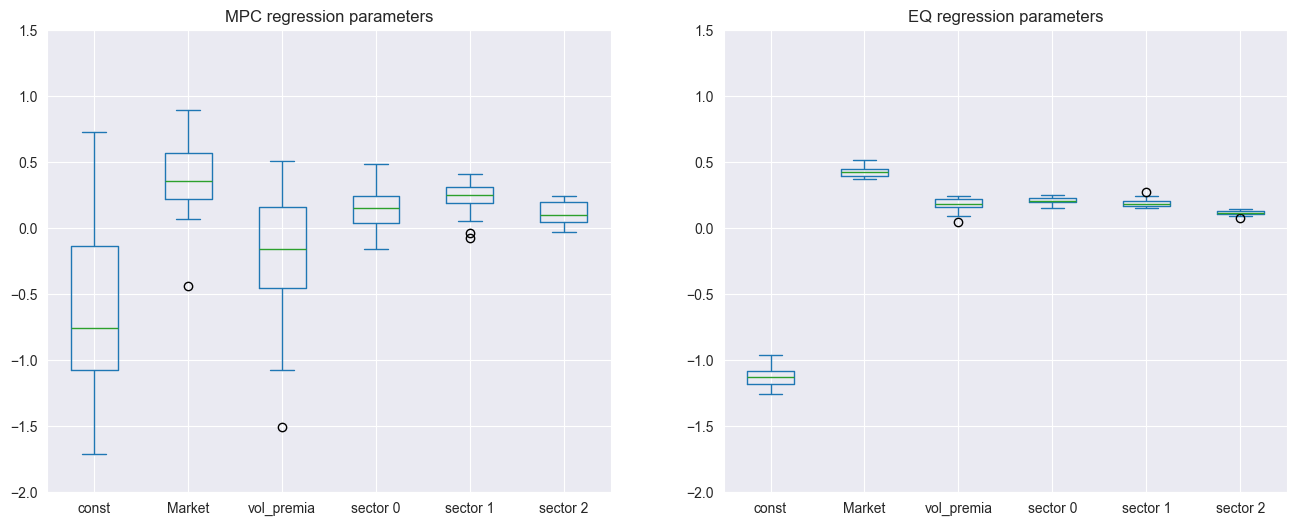

In [147]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

mpc_params_df.T.plot(kind='box', ax=ax[0])
eq_params_df.T.plot(kind='box', ax=ax[1])

ax[0].set_title('MPC regression parameters')
ax[1].set_title('EQ regression parameters')

ax[0].set_ylim(-2, 1.5)
ax[1].set_ylim(-2, 1.5)